# **# 1. Markov Chains**

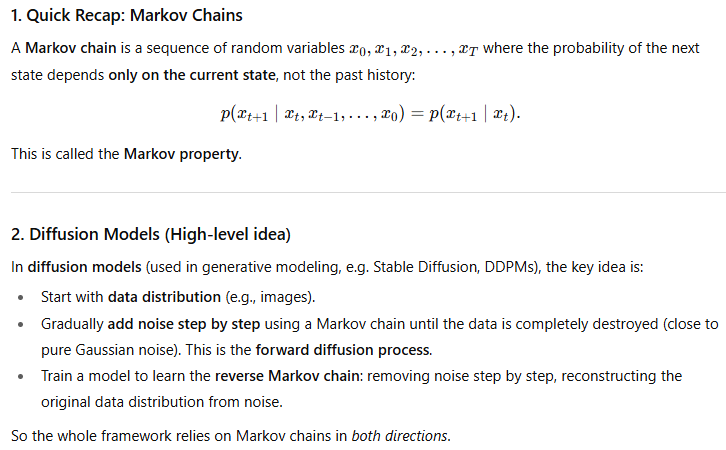

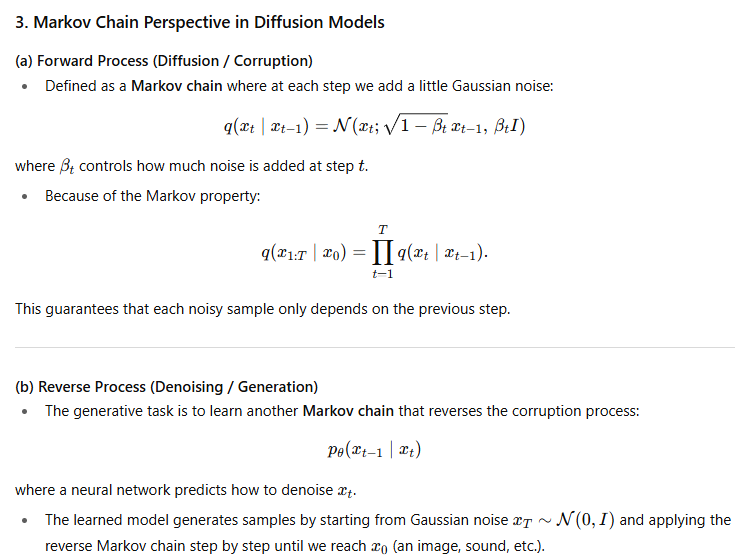

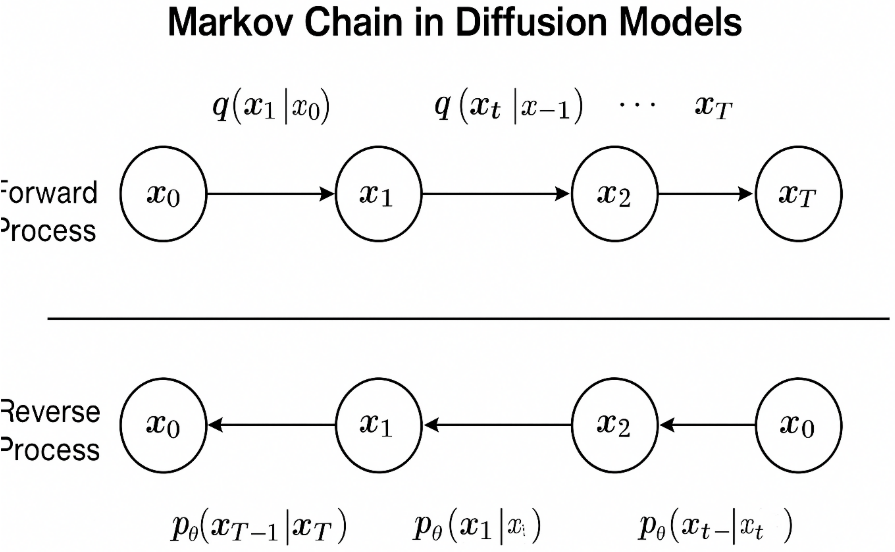

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
MNIST Diffusion (DDPM) — Full script with visualizations
========================================================

What you get:
1) Train a tiny DDPM on MNIST (28x28, grayscale).
2) Save sample grids after each epoch (reverse Markov chain).
3) Save AND (optionally) display:
   • Forward diffusion snapshots (clean → noisy) for a few digits.
   • Noisy inputs vs. denoised outputs, side-by-side.

Run (CPU or GPU):
    pip install torch torchvision matplotlib
    python mnist_diffusion_markov_chain.py --epochs 3 --samples 36 --show

Notebook/Colab friendly: ignores stray args like "-f <kernel.json>".

Markov chains in this script:
• Forward (fixed):  q(x_t | x_{t-1}) = N(√(1-β_t) x_{t-1}, β_t I)
  Closed-form:      x_t = √ᾱ_t x_0 + √(1-ᾱ_t) ε
• Reverse (learned):p_θ(x_{t-1} | x_t) with μ_θ from ε_θ(x_t, t)
  We run x_T → x_0 step-by-step during sampling.
"""

import os
import math
import random
from dataclasses import dataclass
from typing import List, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision as tv
from torchvision.utils import save_image, make_grid
import matplotlib.pyplot as plt


# ----------------------------
# Reproducibility
# ----------------------------

def set_seed(seed: int = 0):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


# ----------------------------
# Schedules & helpers
# ----------------------------

@dataclass
class DiffusionSchedule:
    betas: torch.Tensor
    alphas: torch.Tensor
    alpha_bars: torch.Tensor


def make_linear_beta_schedule(T=200, beta_start=1e-4, beta_end=2e-2, device="cpu"):
    betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32, device=device)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return DiffusionSchedule(betas, alphas, alpha_bars)


def extract(coeffs: torch.Tensor, t: torch.Tensor, shape):
    """
    coeffs: [T]; t: [N] int64; returns coeffs[t] reshaped to broadcast over 'shape'
    """
    t = torch.clamp(t, 0, coeffs.shape[0] - 1)
    out = coeffs.gather(-1, t)
    return out.view(-1, *([1] * (len(shape) - 1)))


# ----------------------------
# Time embedding
# ----------------------------

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int, max_period: int = 10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period

    def forward(self, t: torch.Tensor):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(self.max_period) * torch.arange(0, half, device=t.device, dtype=torch.float32) / half
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=1)
        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))
        return emb


# ----------------------------
# Tiny UNet-ish ε-predictor
# ----------------------------

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, t_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time = nn.Linear(t_dim, out_ch)
        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(x)
        h = h + self.time(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = F.silu(h)
        h = self.conv2(h)
        h = F.silu(h)
        return h + self.skip(x)


class TinyUNet(nn.Module):
    def __init__(self, in_ch=1, base=64, time_dim=128):
        super().__init__()
        self.t_embed = SinusoidalTimeEmbedding(time_dim)
        self.enc1 = ResidualBlock(in_ch, base, time_dim)
        self.enc2 = ResidualBlock(base, base * 2, time_dim)
        self.down = nn.Conv2d(base * 2, base * 2, 4, stride=2, padding=1)  # 28 -> 14
        self.mid = ResidualBlock(base * 2, base * 2, time_dim)
        self.up = nn.ConvTranspose2d(base * 2, base * 2, 4, stride=2, padding=1)  # 14 -> 28
        self.dec2 = ResidualBlock(base * 2, base, time_dim)
        self.dec1 = nn.Conv2d(base, in_ch, 3, padding=1)

    def forward(self, x, t):
        t_emb = self.t_embed(t)
        h1 = self.enc1(x, t_emb)
        h2 = self.enc2(h1, t_emb)
        h3 = self.down(h2)
        h4 = self.mid(h3, t_emb)
        h5 = self.up(h4)
        h5 = h5 + F.interpolate(h2, size=h5.shape[-2:], mode="nearest")
        h6 = self.dec2(h5, t_emb)
        out = self.dec1(h6)
        return out  # ε_θ(x_t, t)


# ----------------------------
# Forward & reverse (Markov steps)
# ----------------------------

@torch.no_grad()
def q_sample_from_x0(x0, t, schedule: DiffusionSchedule, noise=None):
    """
    Closed form forward diffusion (Markov chain):
        x_t = √ᾱ_t x_0 + √(1-ᾱ_t) ε
    """
    if noise is None:
        noise = torch.randn_like(x0)
    a_bar = extract(schedule.alpha_bars, t, x0.shape)
    return a_bar.sqrt() * x0 + (1.0 - a_bar).sqrt() * noise


def p_mean_variance(model, x_t, t, schedule: DiffusionSchedule):
    """
    Reverse diffusion parameters:
      μ_θ = (1/√α_t) * ( x_t - ((1-α_t)/√(1-ᾱ_t)) * ε_θ(x_t, t) )
      σ_t^2 = β_t * (1-ᾱ_{t-1}) / (1-ᾱ_t)
    """
    betas, alphas, a_bars = schedule.betas, schedule.alphas, schedule.alpha_bars
    eps_theta = model(x_t, t)
    a_t = extract(alphas, t, x_t.shape)
    a_bar_t = extract(a_bars, t, x_t.shape)
    beta_t = extract(betas, t, x_t.shape)
    a_bar_prev = extract(a_bars, t - 1, x_t.shape)

    coef = (1.0 - a_t) / (1.0 - a_bar_t).sqrt()
    mu = (1.0 / a_t.sqrt()) * (x_t - coef * eps_theta)
    var = beta_t * (1.0 - a_bar_prev) / (1.0 - a_bar_t)
    return mu, var


@torch.no_grad()
def p_sample_step(model, x_t, t, schedule: DiffusionSchedule):
    mu, var = p_mean_variance(model, x_t, t, schedule)
    if (t == 0).all():
        return mu  # last step often taken without noise
    noise = torch.randn_like(x_t)
    return mu + var.sqrt() * noise


@torch.no_grad()
def sample_from_noise(model, n, img_size, schedule: DiffusionSchedule, device, save_path: Optional[str] = None):
    """
    Run the reverse Markov chain from x_T ~ N(0, I) to x_0.
    """
    T = schedule.betas.shape[0]
    x = torch.randn(n, 1, img_size, img_size, device=device)
    for ti in reversed(range(T)):
        t = torch.full((n,), ti, device=device, dtype=torch.long)
        x = p_sample_step(model, x, t, schedule)
    x01 = (x.clamp(-1, 1) + 1) * 0.5
    if save_path:
        grid = make_grid(x01, nrow=int(math.sqrt(n)))
        save_image(grid, save_path)
    return x01


@torch.no_grad()
def sample_from_xt(model, x_t, t_start: int, schedule: DiffusionSchedule):
    """
    Denoise from an intermediate time t_start down to 0 using the learned reverse chain.
    """
    x = x_t
    for ti in reversed(range(t_start + 1)):
        t = torch.full((x.size(0),), ti, device=x.device, dtype=torch.long)
        x = p_sample_step(model, x, t, schedule)
    return (x.clamp(-1, 1) + 1) * 0.5


# ----------------------------
# Visualization helpers
# ----------------------------

def _ensure_dir(path: str):
    os.makedirs(path, exist_ok=True)


def show_images(images: torch.Tensor, title: str = "", nrow: int = 8, show: bool = True, save_path: Optional[str] = None):
    """
    images: [N,1,28,28] in [0,1] or [-1,1]. We auto-clamp+scale to [0,1] for display.
    """
    img01 = (images.clamp(-1, 1) + 1) * 0.5
    grid = make_grid(img01, nrow=nrow)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
    plt.axis("off")
    plt.title(title)
    if save_path:
        _ensure_dir(os.path.dirname(save_path))
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    if show:
        plt.show()
    plt.close()


@torch.no_grad()
def visualize_forward_diffusion(x0: torch.Tensor,
                                schedule: DiffusionSchedule,
                                steps: List[int],
                                out_dir: str,
                                prefix: str,
                                show: bool):
    """
    Show how a *few* clean digits get corrupted over increasing t.
    Saves a panel image and (optionally) displays it.
    """
    _ensure_dir(out_dir)
    x0 = x0[:8]  # use 8 examples for a tidy grid
    cols = len(steps) + 1
    rows = x0.size(0)

    # Build a panel: for each row (image), first col is x0, next cols are x_t at different steps
    panels = []
    for i in range(rows):
        row_imgs = []
        row_imgs.append(x0[i:i+1])
        for step in steps:
            t = torch.full((1,), int(step), device=x0.device, dtype=torch.long)
            xt = q_sample_from_x0(x0[i:i+1], t, schedule)
            row_imgs.append(xt)
        row_imgs = torch.cat(row_imgs, dim=0)  # [cols,1,28,28]
        panels.append(row_imgs)
    panels = torch.cat(panels, dim=0)  # [rows*cols,1,28,28]

    title = f"Forward diffusion (clean → noisy). Columns: x0, t={steps}"
    save_path = os.path.join(out_dir, f"{prefix}_forward_panel.png")
    show_images(panels, title=title, nrow=cols, show=show, save_path=save_path)


@torch.no_grad()
def visualize_noisy_vs_denoised(model,
                                schedule: DiffusionSchedule,
                                x0_batch: torch.Tensor,
                                t_start: int,
                                out_dir: str,
                                prefix: str,
                                show: bool):
    """
    Make a grid with two rows: 'Noisy at t=t_start' and 'Denoised to t=0'.
    Also save separate grids for inputs and outputs.
    """
    _ensure_dir(out_dir)
    x0 = x0_batch[:16]
    t = torch.full((x0.size(0),), t_start, device=x0.device, dtype=torch.long)
    x_noisy = q_sample_from_x0(x0, t, schedule)              # noisy inputs at t_start
    x_denoised = sample_from_xt(model, x_noisy.clone(), t_start, schedule)  # denoised outputs

    # Save/show inputs
    show_images(x_noisy, title=f"Noisy inputs at t={t_start}", nrow=8, show=show,
                save_path=os.path.join(out_dir, f"{prefix}_noisy_t{t_start}.png"))

    # Save/show outputs
    show_images(x_denoised, title="Denoised outputs (reverse Markov chain to t=0)", nrow=8, show=show,
                save_path=os.path.join(out_dir, f"{prefix}_denoised_from_t{t_start}.png"))

    # Combined panel: interleave input/output pairs row-wise
    combined = torch.stack([((x_noisy.clamp(-1, 1) + 1) * 0.5),
                            x_denoised], dim=1)  # [N,2,1,28,28]
    combined = combined.view(-1, 1, 28, 28)     # [2N,1,28,28]
    show_images(combined, title=f"Noisy (t={t_start}) vs Denoised", nrow=8, show=show,
                save_path=os.path.join(out_dir, f"{prefix}_noisy_vs_denoised_t{t_start}.png"))


# ----------------------------
# Training & evaluation
# ----------------------------

def train(
    data="./data", out="./outputs", epochs=3, batch_size=128, lr=2e-4,
    T=200, beta_start=1e-4, beta_end=2e-2, samples=36, show=False, seed=0
):
    set_seed(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Device: {device}")

    # Data: MNIST in [-1,1]
    tfm = tv.transforms.Compose([
        tv.transforms.ToTensor(),
        tv.transforms.Lambda(lambda x: x * 2.0 - 1.0)
    ])
    train_set = tv.datasets.MNIST(root=data, train=True, download=True, transform=tfm)
    test_set = tv.datasets.MNIST(root=data, train=False, download=True, transform=tfm)
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2, drop_last=True)
    test_loader = DataLoader(test_set, batch_size=32, shuffle=True, num_workers=2, drop_last=True)

    model = TinyUNet(in_ch=1, base=64, time_dim=128).to(device)
    schedule = make_linear_beta_schedule(T=T, beta_start=beta_start, beta_end=beta_end, device=device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)

    _ensure_dir(out)

    # Demo a pre-training forward panel
    x0_demo, _ = next(iter(test_loader))
    x0_demo = x0_demo.to(device)
    forward_steps = sorted({1, T//10, T//5, T//2, T-1})
    visualize_forward_diffusion(x0_demo, schedule, steps=forward_steps, out_dir=out,
                                prefix="epoch0", show=show)

    # Train (ε-prediction objective)
    model.train()
    for epoch in range(1, epochs + 1):
        for i, (x0, _) in enumerate(train_loader, start=1):
            x0 = x0.to(device)
            t = torch.randint(1, T, (x0.size(0),), device=device)
            eps = torch.randn_like(x0)
            x_t = q_sample_from_x0(x0, t, schedule, noise=eps)  # forward (closed-form)

            eps_pred = model(x_t, t)                             # predict noise
            loss = F.mse_loss(eps_pred, eps)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            if i % 200 == 0:
                print(f"Epoch {epoch} | step {i}/{len(train_loader)} | loss {loss.item():.4f}")

        # After each epoch: 1) sample from pure noise, 2) visualize noisy vs denoised, 3) visualize forward again
        model.eval()
        with torch.no_grad():
            # 1) Reverse chain samples from noise
            samples_path = os.path.join(out, f"samples_epoch{epoch}.png")
            print(f"[Sampling] writing {samples_path}")
            sample_from_noise(model, n=samples, img_size=28, schedule=schedule, device=device, save_path=samples_path)

            # 2) Noisy vs denoised on a fresh test batch
            x0_eval, _ = next(iter(test_loader))
            x0_eval = x0_eval.to(device)
            t_start = T - 1
            visualize_noisy_vs_denoised(model, schedule, x0_eval, t_start=t_start,
                                        out_dir=out, prefix=f"epoch{epoch}", show=show)

            # 3) Forward panel again for comparison
            visualize_forward_diffusion(x0_eval, schedule, steps=forward_steps, out_dir=out,
                                        prefix=f"epoch{epoch}", show=show)

        model.train()

    # Save weights
    wpath = os.path.join(out, "mnist_ddpm_tinyunet.pt")
    torch.save({"model": model.state_dict(),
                "hparams": dict(epochs=epochs, batch_size=batch_size, lr=lr, T=T,
                                beta_start=beta_start, beta_end=beta_end, samples=samples, seed=seed)}, wpath)
    print(f"Saved weights to {wpath}")

    print("\nRecap:")
    print("• Forward chain q(x_t | x_{t-1}) is a fixed Gaussian noising process (Markov).")
    print("• Reverse chain p_θ(x_{t-1} | x_t) is learned; sampling runs it step-by-step from x_T to x_0.")
    print(f"Images written to: {os.path.abspath(out)}")


def sample_only(weights, out="./outputs", samples=36, T=200, beta_start=1e-4, beta_end=2e-2, show=False, seed=0):
    set_seed(seed)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    schedule = make_linear_beta_schedule(T=T, beta_start=beta_start, beta_end=beta_end, device=device)
    model = TinyUNet(in_ch=1, base=64, time_dim=128).to(device)
    ckpt = torch.load(weights, map_location=device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    _ensure_dir(out)
    out_path = os.path.join(out, "samples_from_weights.png")
    imgs = sample_from_noise(model, n=samples, img_size=28, schedule=schedule, device=device, save_path=out_path)
    print(f"Saved {out_path}")
    # Optionally display
    if show:
        show_images(imgs, title="Samples (loaded weights)", nrow=int(math.sqrt(samples)), show=True,
                    save_path=None)


# ----------------------------
# Notebook/CLI friendly entry
# ----------------------------

def main():
    import argparse
    p = argparse.ArgumentParser(description="MNIST Diffusion (DDPM) — Markov chain with visuals", add_help=True)
    p.add_argument("--data", type=str, default="./data", help="dataset dir")
    p.add_argument("--out", type=str, default="./outputs", help="output dir")
    p.add_argument("--epochs", type=int, default=3)
    p.add_argument("--batch_size", type=int, default=128)
    p.add_argument("--lr", type=float, default=2e-4)
    p.add_argument("--T", type=int, default=200, help="diffusion steps")
    p.add_argument("--beta_start", type=float, default=1e-4)
    p.add_argument("--beta_end", type=float, default=2e-2)
    p.add_argument("--samples", type=int, default=36, help="grid = sqrt(samples) x sqrt(samples)")
    p.add_argument("--weights", type=str, default="", help="if set, run sample-only from weights")
    p.add_argument("--show", action="store_true", help="display images inline using matplotlib")
    p.add_argument("--seed", type=int, default=0, help="random seed")
    # Ignore unknown args (e.g., '-f' from Jupyter kernels)
    args, _unknown = p.parse_known_args()

    if args.weights:
        sample_only(args.weights, out=args.out, samples=args.samples, T=args.T,
                    beta_start=args.beta_start, beta_end=args.beta_end, show=args.show, seed=args.seed)
    else:
        train(
            data=args.data, out=args.out, epochs=args.epochs, batch_size=args.batch_size, lr=args.lr,
            T=args.T, beta_start=args.beta_start, beta_end=args.beta_end, samples=args.samples,
            show=args.show, seed=args.seed
        )


if __name__ == "__main__":
    main()


Device: cuda
Epoch 1 | step 200/468 | loss 0.1179
Epoch 1 | step 400/468 | loss 0.0845
[Sampling] writing ./outputs/samples_epoch1.png
Epoch 2 | step 200/468 | loss 0.0693
Epoch 2 | step 400/468 | loss 0.0650
[Sampling] writing ./outputs/samples_epoch2.png
Epoch 3 | step 200/468 | loss 0.0609
Epoch 3 | step 400/468 | loss 0.0561
[Sampling] writing ./outputs/samples_epoch3.png
Saved weights to ./outputs/mnist_ddpm_tinyunet.pt

Recap:
• Forward chain q(x_t | x_{t-1}) is a fixed Gaussian noising process (Markov).
• Reverse chain p_θ(x_{t-1} | x_t) is learned; sampling runs it step-by-step from x_T to x_0.
Images written to: /content/outputs


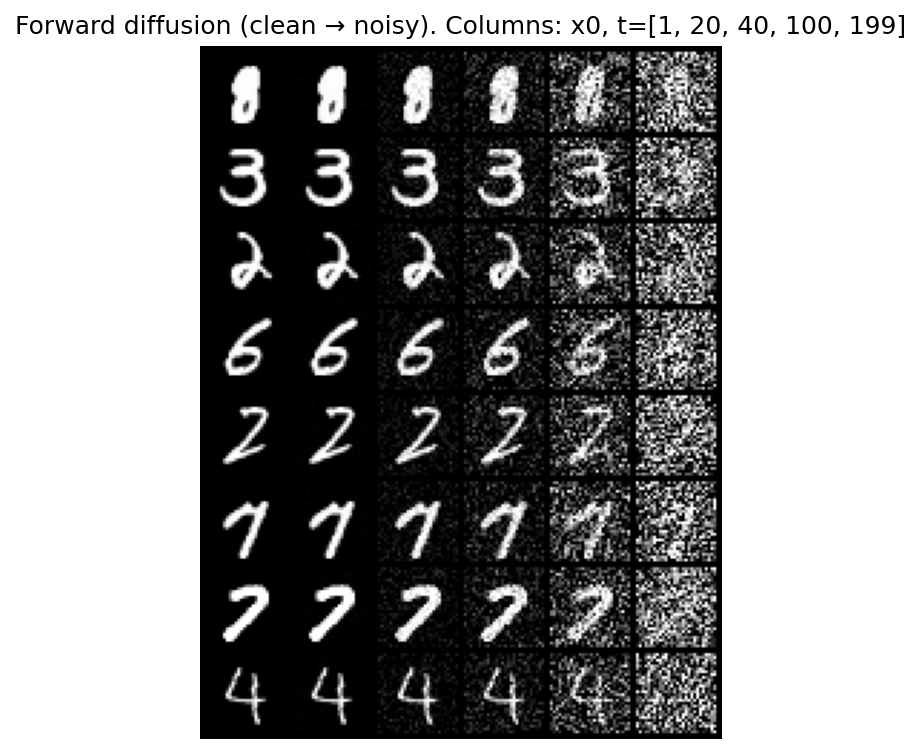

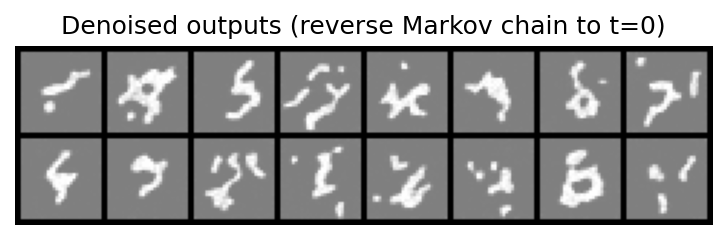

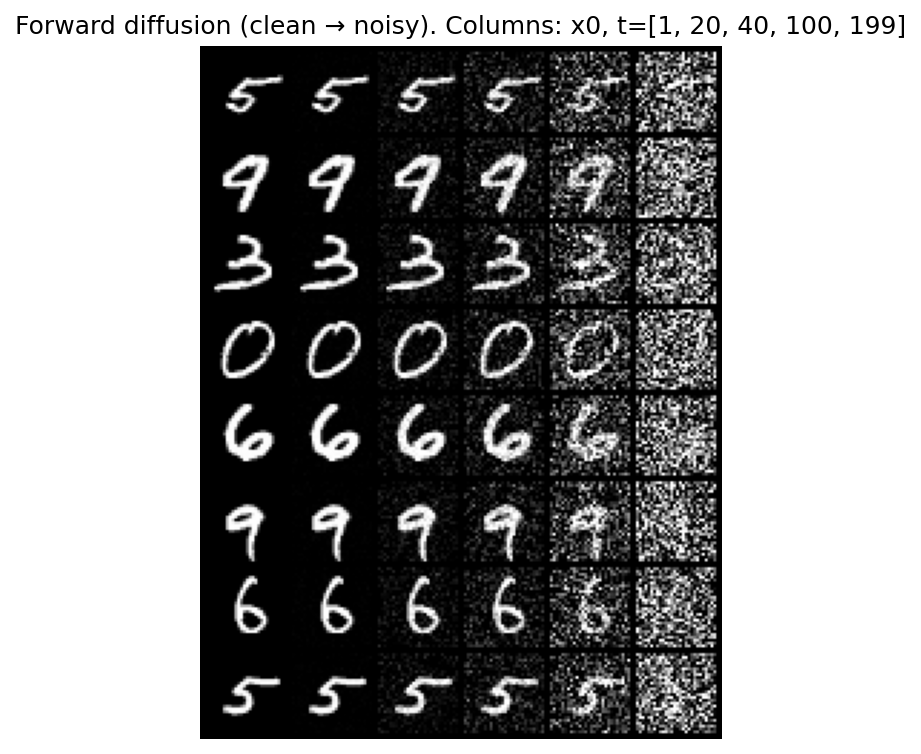

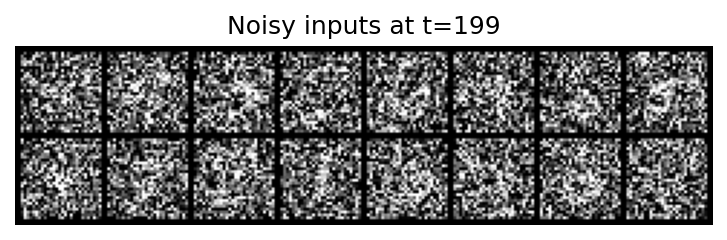

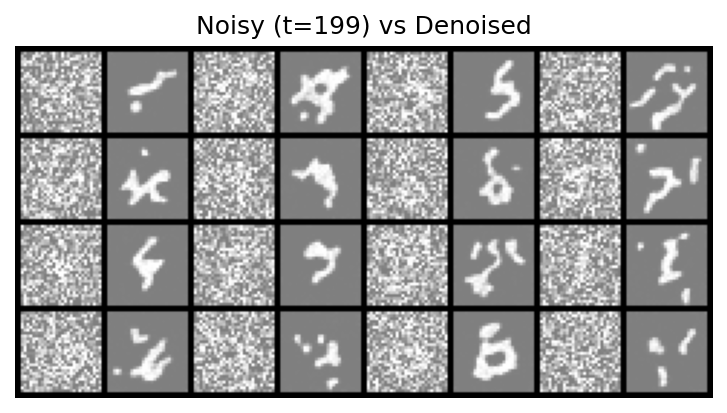

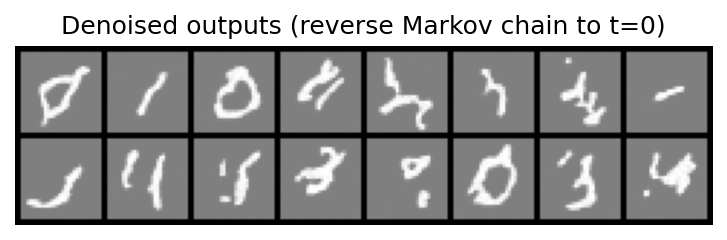

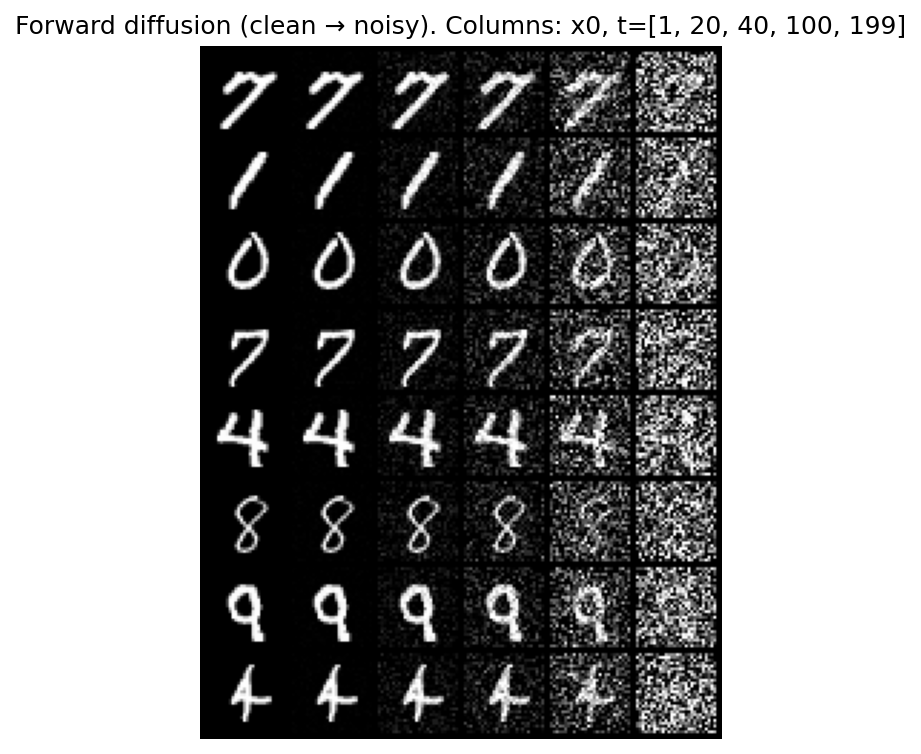

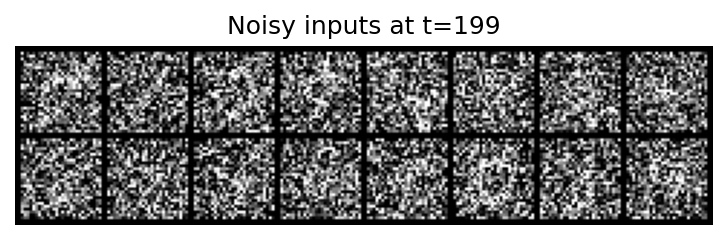

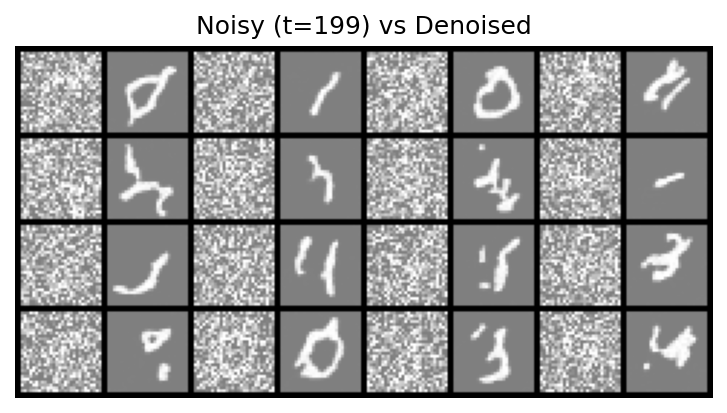

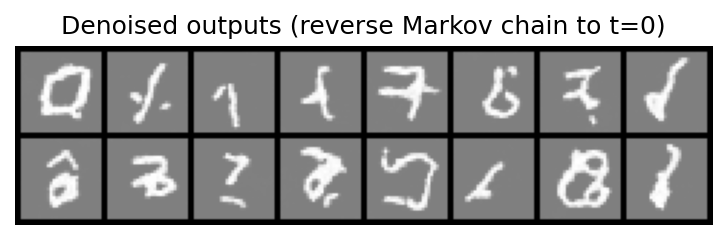

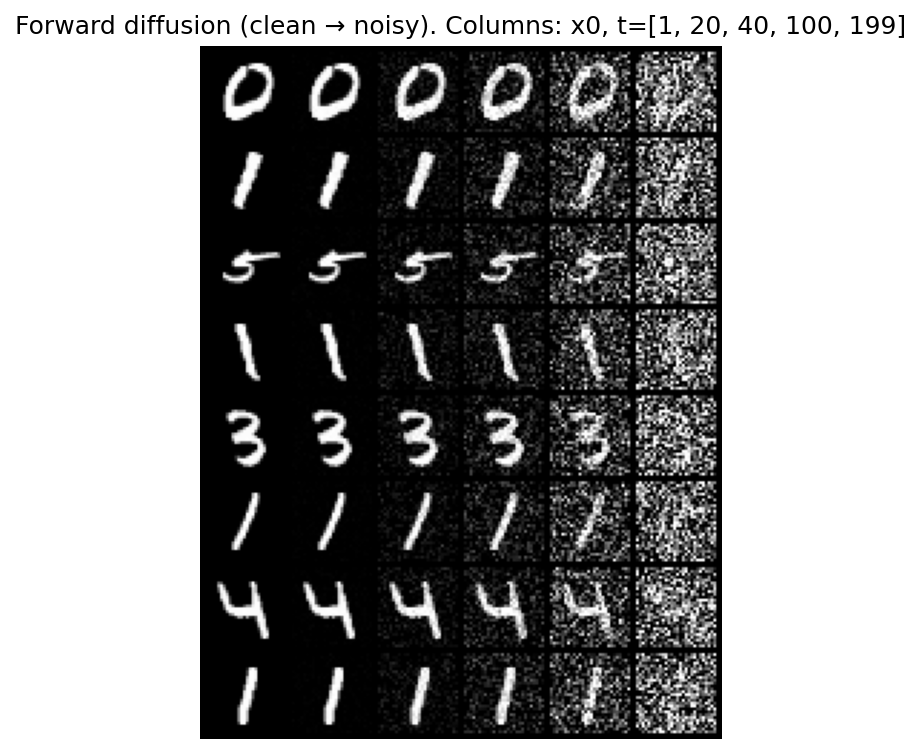

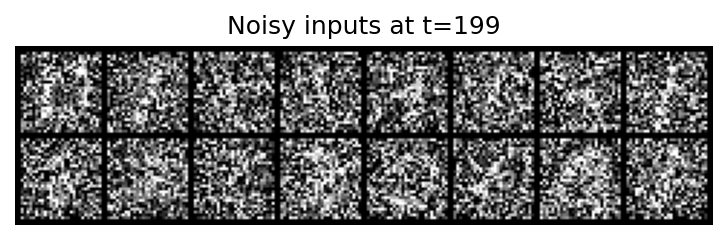

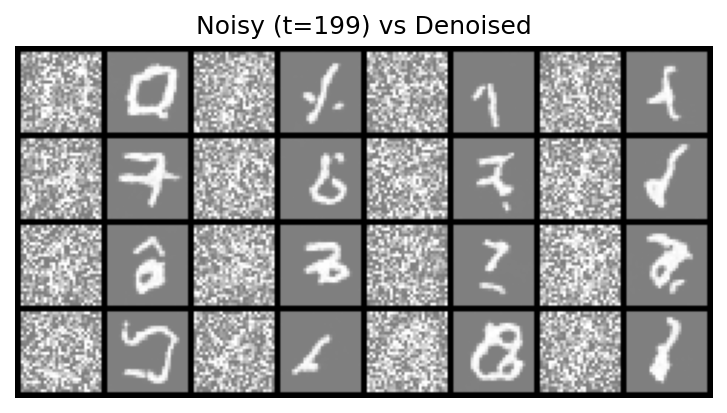

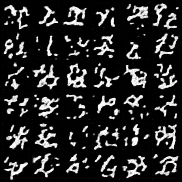

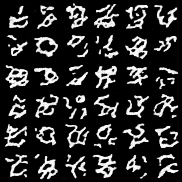

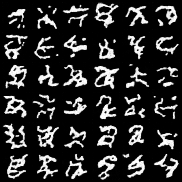

In [ ]:
import glob, os
from IPython.display import display, Image, HTML

imgs = sorted(glob.glob("./outputs/*.png"))
if not imgs:
    print("No images found in ./outputs")
else:
    display(HTML("<h3>Saved outputs</h3>"))
    for p in imgs:
        display(HTML(f"<b>{os.path.basename(p)}</b>"))
        display(Image(filename=p))


# **# 2. Jensen-Shannon**

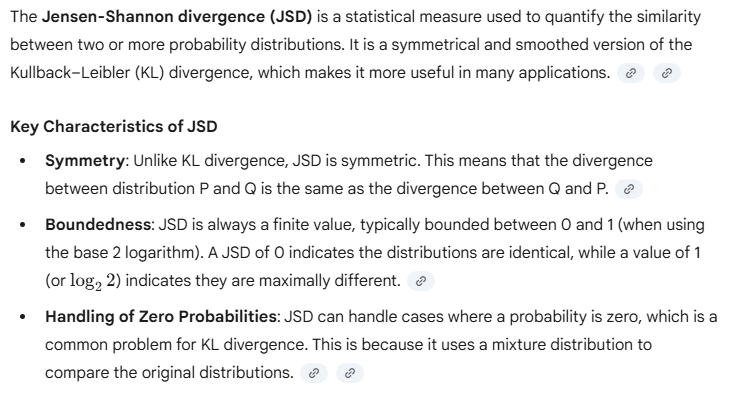

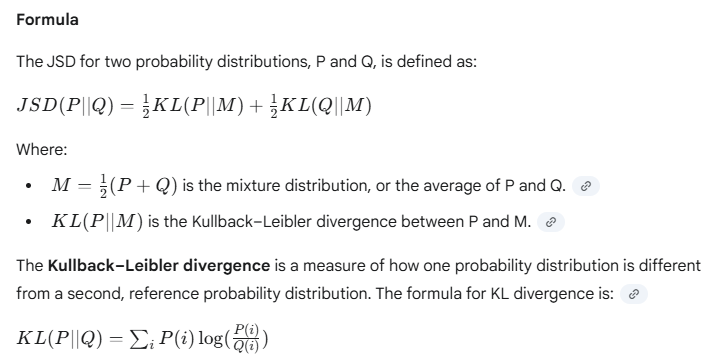

# **# 3. Kullback Leibler**

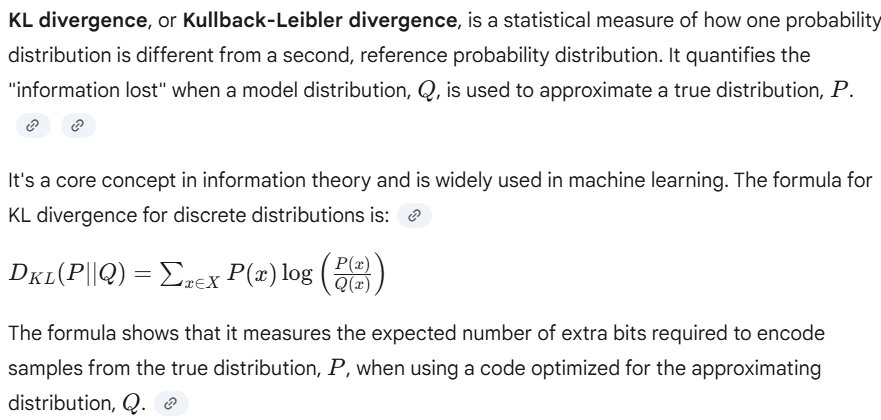

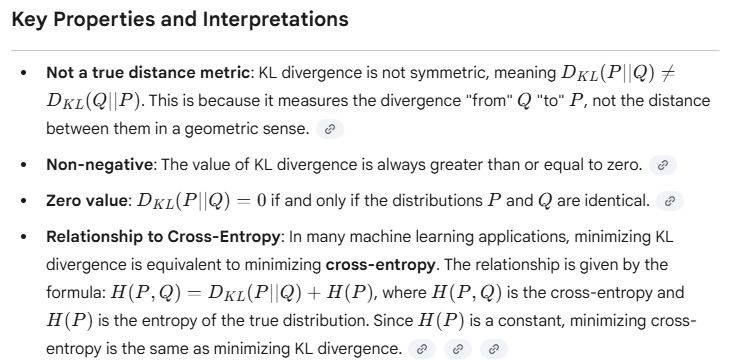

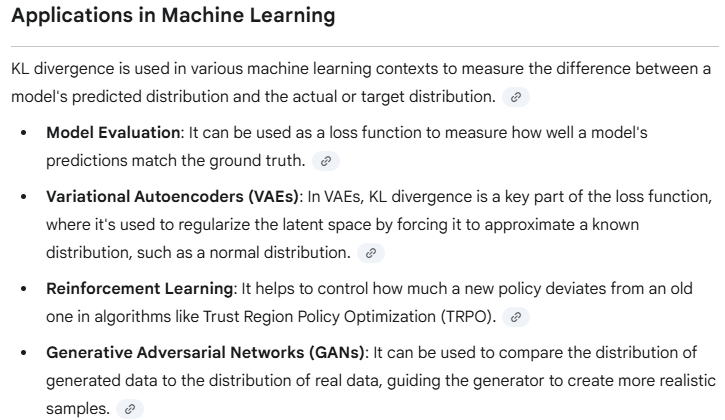

image.png

In [ ]:
import numpy as np
from scipy.stats import entropy, norm


p = np.array([0.4, 0.6])   # Distribution P
q = np.array([0.5, 0.5])   # Distribution Q

kl_qp = entropy(q, p)   # KL(Q||P)
kl_pq = entropy(p, q)   # KL(P||Q)

print("KL(Q||P):", kl_qp)
print("KL(P||Q):", kl_pq)


KL(Q||P): 0.02041099726012756
KL(P||Q): 0.020135513550688863


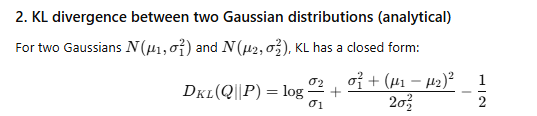

In [ ]:
def kl_gaussian(mu1, sigma1, mu2, sigma2):
    return np.log(sigma2/sigma1) + (sigma1**2 + (mu1-mu2)**2)/(2*sigma2**2) - 0.5

print("KL between N(0,1) and N(1,1):", kl_gaussian(0,1,1,1))
print("KL between N(0,1) and N(0,2):", kl_gaussian(0,1,0,2))


KL between N(0,1) and N(1,1): 0.5
KL between N(0,1) and N(0,2): 0.3181471805599453


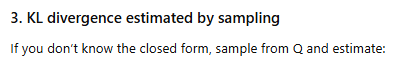

In [ ]:
samples = np.random.normal(loc=0, scale=1, size=10000)  # from Q = N(0,1)
q_pdf = norm.pdf(samples, 0, 1)
p_pdf = norm.pdf(samples, 1, 1)

kl_estimate = np.mean(np.log(q_pdf / p_pdf))
print("Estimated KL(Q||P):", kl_estimate)


Estimated KL(Q||P): 0.5076574357243602


4. KL divergence between categorical distributions (multi-class)

In [ ]:
p = np.array([0.1, 0.2, 0.7])   # P distribution
q = np.array([0.2, 0.2, 0.6])   # Q distribution

print("KL(Q||P):", entropy(q, p))

KL(Q||P): 0.04613902821563409


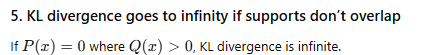

In [ ]:
p = np.array([1.0, 0.0])   # P puts all mass on first outcome
q = np.array([0.5, 0.5])   # Q spreads mass

print("KL(Q||P):", entropy(q, p))  # should be inf

KL(Q||P): inf


===  2025 Tmax KL Divergence ===
D_KL(Forecast || Actual) = 0.000 nats
JS(Forecast, Actual)     = 0.000 nats


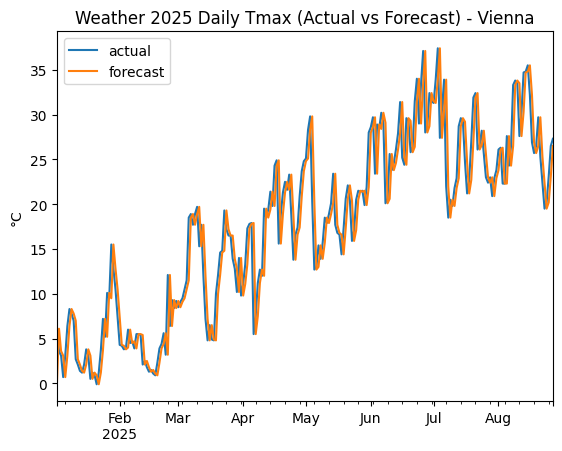

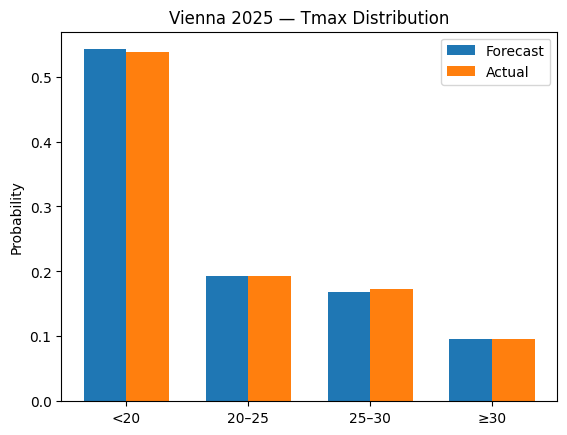

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Vienna (Austria) daily Tmax — KL divergence of forecast vs actual (2025 demo)

Fix:
- Use ERA5 archive only up to "yesterday" (since 2025 is current year).
- Use Open-Meteo forecast API for today → ~7 days ahead.
- Use persistence baseline for the earlier part of 2025.

Plots:
- Actual vs forecast Tmax time series
- Histogram distributions
- KL/JS divergence metrics
"""

import requests, numpy as np, pandas as pd, matplotlib.pyplot as plt, datetime as dt

LAT, LON = 48.208, 16.373

# ---------- KL utilities ----------
def dkl_discrete(q, p, eps=1e-12):
    q = np.asarray(q,float); p = np.asarray(p,float)
    q += eps; p += eps
    q /= q.sum(); p /= p.sum()
    return float(np.sum(q*np.log(q/p)))

def jensen_shannon(q,p,eps=1e-12):
    q = np.asarray(q,float); p = np.asarray(p,float)
    q += eps; p += eps
    q /= q.sum(); p /= p.sum()
    m = 0.5*(q+p)
    return 0.5*dkl_discrete(q,m)+0.5*dkl_discrete(p,m)

def parse_bins(bins_str):
    def edge(x):
        if x=="-inf": return -1e12
        if x in ("inf","+inf"): return 1e12
        return float(x)
    edges = np.array([edge(b.strip()) for b in bins_str.split(",")])
    labels=[]
    for i in range(len(edges)-1):
        a,b=edges[i],edges[i+1]
        if a<=-1e11: labels.append(f"<{int(b)}")
        elif b>=1e11: labels.append(f"≥{int(a)}")
        else: labels.append(f"{int(a)}–{int(b)}")
    return edges,labels

# ---------- Data ----------
def fetch_actual_2025_until_yesterday():
    today = dt.date.today()
    start="2025-01-01"
    end=(today-dt.timedelta(days=1)).strftime("%Y-%m-%d")
    url=(f"https://archive-api.open-meteo.com/v1/era5?"
         f"latitude={LAT}&longitude={LON}&daily=temperature_2m_max"
         f"&start_date={start}&end_date={end}&timezone=Europe%2FVienna")
    r=requests.get(url,timeout=30); r.raise_for_status()
    js=r.json()
    dates=pd.to_datetime(js["daily"]["time"])
    return pd.Series(js["daily"]["temperature_2m_max"],index=dates,name="actual")

def fetch_forecast_next7():
    url=(f"https://api.open-meteo.com/v1/forecast?"
         f"latitude={LAT}&longitude={LON}&daily=temperature_2m_max"
         f"&forecast_days=7&timezone=Europe%2FVienna")
    r=requests.get(url,timeout=30); r.raise_for_status()
    js=r.json()
    dates=pd.to_datetime(js["daily"]["time"])
    return pd.Series(js["daily"]["temperature_2m_max"],index=dates,name="forecast")

def build_persistence_forecast(actual):
    return actual.shift(1).rename("forecast")

# ---------- Main ----------
def main():
    edges,labels=parse_bins("-inf,20,25,30,inf")

    actual=fetch_actual_2025_until_yesterday()
    forecast_future=fetch_forecast_next7()
    persistence=build_persistence_forecast(actual)

    # combine: persistence until yesterday, forecast afterwards
    forecast=pd.concat([persistence,forecast_future]).sort_index()
    df=pd.concat([actual,forecast],axis=1)

    # Drop leading NaN from persistence
    df=df.dropna()

    # --- Distribution comparison
    Q,_=np.histogram(df["forecast"],bins=edges)
    P,_=np.histogram(df["actual"],bins=edges)
    kl_fp=dkl_discrete(Q,P)
    js=jensen_shannon(Q,P)

    print("===  2025 Tmax KL Divergence ===")
    print(f"D_KL(Forecast || Actual) = {kl_fp:.3f} nats")
    print(f"JS(Forecast, Actual)     = {js:.3f} nats")

    # --- Plot actual vs forecast
    df.plot(y=["actual","forecast"],title="Weather 2025 Daily Tmax (Actual vs Forecast) - Vienna")
    plt.ylabel("°C"); plt.show()

    # --- Plot histogram distributions
    x=np.arange(len(labels))
    width=0.35
    plt.bar(x-width/2,Q/Q.sum(),width,label="Forecast")
    plt.bar(x+width/2,P/P.sum(),width,label="Actual")
    plt.xticks(x,labels)
    plt.title("Vienna 2025 — Tmax Distribution")
    plt.ylabel("Probability"); plt.legend(); plt.show()

if __name__=="__main__":
    main()


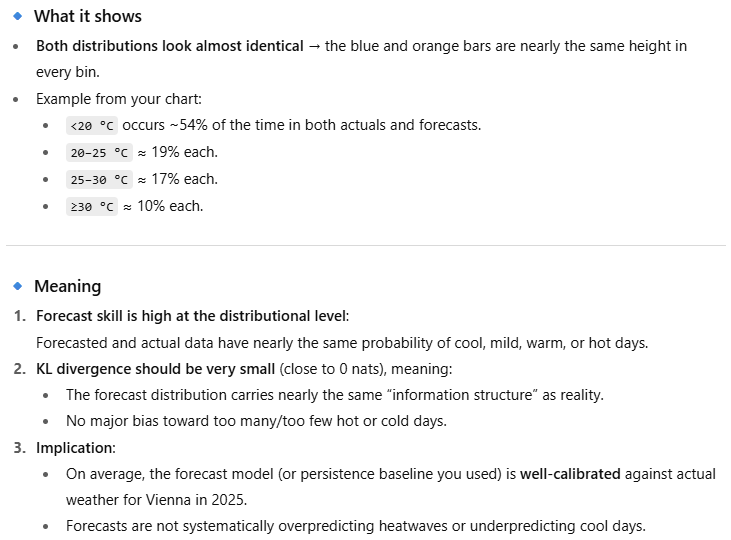

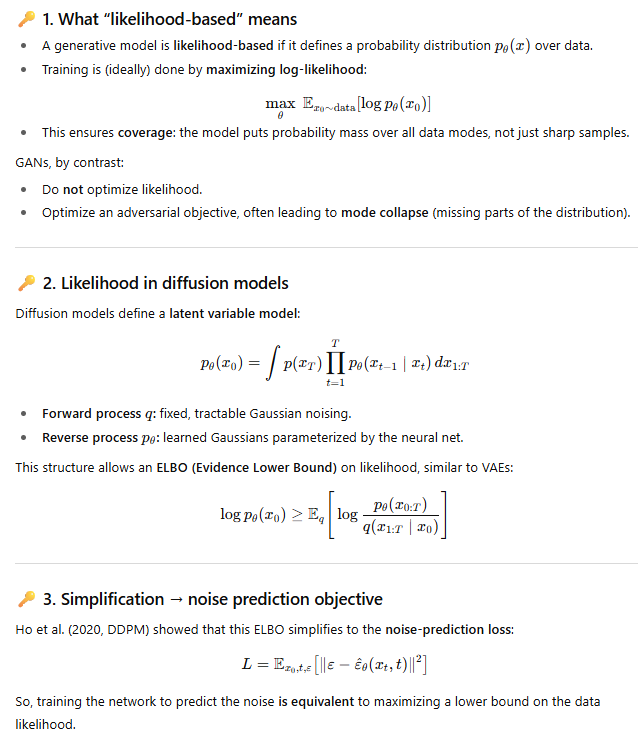

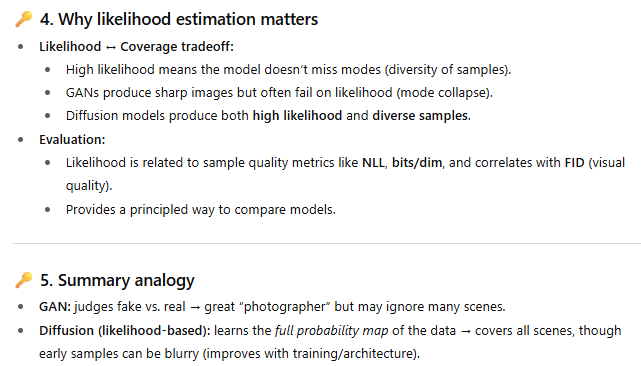